In [12]:
import numpy as np
import pandas as pd
import os
import pathlib
from scipy.stats import gaussian_kde
from tqdm import tqdm
import warnings
import seaborn as sns
from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from scipy import stats as _stats
from matplotlib.colors import to_hex
from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile
import liffile
import napari
import colorsys
from collections import defaultdict

from PIL import ImageColor
warnings.filterwarnings("ignore")

In [20]:
def create_n_valued_palette(base_colour_hex, n=5):
    r, g, b = ImageColor.getcolor(base_colour_hex, "RGB")
    r, g, b = r/255, g/255, b/255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    adjustments = np.linspace(0.5, 1.4, n)
    palette = []
    for a in adjustments:
        l_adj = min(max(l * a, 0), 1)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        palette.append(to_hex(rgb))
    return palette

# Default palette: add/change entries here to introduce new groups
DEFAULT_PALETTE = {
    "ARi": "#ff0000",
    "UTD": "#1e90ff",
}


In [3]:


# ── helper: count cells inside/outside a region ─────────────────────────────
def _cell_counts_in_region(cell_mask, region_mask):
    labeled = label(cell_mask)
    n_total = int(labeled.max())
    if n_total == 0:
        return 0, 0, 0, 0
    props_df = pd.DataFrame(regionprops_table(labeled, properties=("centroid",)))
    rows = np.clip(np.round(props_df["centroid-0"].values).astype(int), 0, region_mask.shape[0] - 1)
    cols = np.clip(np.round(props_df["centroid-1"].values).astype(int), 0, region_mask.shape[1] - 1)
    in_region = region_mask.astype(bool)[rows, cols]
    n_in  = int(in_region.sum())
    n_out = n_total - n_in
    pix_in  = int(np.sum(cell_mask.astype(bool) & region_mask.astype(bool)))
    pix_out = int(np.sum(cell_mask.astype(bool) & ~region_mask.astype(bool)))
    return n_in, n_out, pix_in, pix_out


# ── QC figure: show segmented regions overlaid on their source channel ───────
def save_qc_figure(img_name, panels, out_dir, solidity_info=None):
    """Save a 2-row QC figure.
    panels: list of (title, raw_channel, mask) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour.
    solidity_info: optional dict {"chip": float, "vasculature": float}"""
    n = len(panels)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), constrained_layout=True)
    sol_str = ""
    if solidity_info:
        parts = [f"{k} solidity={v:.3f}" for k, v in solidity_info.items()]
        sol_str = "  |  " + "  |  ".join(parts)
    fig.suptitle(f"Segmentation QC — {img_name}{sol_str}", fontsize=11, fontweight="bold")
    for col, (title, raw, mask) in enumerate(panels):
        axes[0, col].imshow(raw, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(raw, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw.shape, 4), dtype=float)
        overlay[mask, :] = [1, 0.2, 0.2, 0.5]
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title("mask", fontsize=8)
        axes[1, col].axis("off")
    safe_name = img_name.replace('/', '_')
    sol_tag = ""
    if solidity_info:
        sol_tag = "_chip{:.3f}_vasc{:.3f}".format(
            solidity_info.get("chip", 0), solidity_info.get("vasculature", 0))
    out_path = out_dir / f"{safe_name}{sol_tag}_QC.png"
    fig.savefig(out_path, dpi=80, bbox_inches="tight")
    plt.close(fig)
    return out_path


def _save_threshold_qc(smoothed, img_name, out_dir):
    """Save a try_all_threshold figure for the smoothed device channel."""
    fig, axes = try_all_threshold(smoothed, figsize=(12, 8), verbose=False)
    fig.suptitle(f"Threshold comparison — {img_name}", fontsize=11, fontweight="bold")
    safe_name = img_name.replace('/', '_')
    out_path = out_dir / f"{safe_name}_threshold_QC.png"
    fig.savefig(out_path, dpi=80, bbox_inches="tight")
    plt.close(fig)
    return out_path


# ── main per-image analysis function ────────────────────────────────────────
# Colocalisation scales (µm)
GAUSS_SIGMAS_UM    = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]

def analyse_image(img, qc_dir=None):
    """Run the full segmentation + counting + colocalisation pipeline on one LifImage.
    Returns (df_counts, df_distances, df_coloc, qc_panels, solidity_info).
    """
    from skimage.morphology import closing, disk

    data = img.asarray()
    z_axis = img.dims.index('Z')
    mx = np.max(data, axis=z_axis)   # shape: (C, Y, X)

    # --- segmentation ---
    vasculature_raw    = mx[3]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    smooth_vasc        = gaussian(vasculature_median, sigma=3)
    seg_vasculature    = smooth_vasc > threshold_triangle(smooth_vasc)

    # If the largest component is implausibly solid (> 0.9), retry with threshold_li
    _vasc_lbl = label(seg_vasculature)
    _vasc_rpt = pd.DataFrame(regionprops_table(_vasc_lbl, properties=("area", "solidity")))
    if not _vasc_rpt.empty:
        _vasc_sol = float(_vasc_rpt.loc[_vasc_rpt["area"].idxmax(), "solidity"])
        if _vasc_sol > 0.9:
            seg_vasculature = smooth_vasc > threshold_li(smooth_vasc)

    device  = mx[1]
    clipped = np.clip(device, np.percentile(device, 25), np.percentile(device, 90))
    smoothed = gaussian(clipped, sigma=7)

    # Save threshold comparison QC figure
    if qc_dir is not None:
        _save_threshold_qc(smoothed, img.name, qc_dir)

    # --- Left / Right / Chip segmentation (fill from edges) ---
    bright = smoothed > threshold_li(smoothed)
    labeled_bright = label(bright)

    # Left region: bright components that touch the left edge (column 0)
    left_labels = set(labeled_bright[:, 0]) - {0}
    left_region = np.isin(labeled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    # Right region: bright components that touch the right edge (last column)
    right_labels = set(labeled_bright[:, -1]) - {0}
    right_region = np.isin(labeled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    # Chip = remaining region between left and right
    chip = ~left_region & ~right_region

    # Chip solidity
    labeled_chip = label(chip)
    chip_props = pd.DataFrame(regionprops_table(
        labeled_chip, properties=("label", "area", "solidity")))
    if not chip_props.empty:
        chip_solidity = chip_props.loc[chip_props["area"].idxmax(), "solidity"]
    else:
        chip_solidity = 0.0
    print(f"  Chip solidity: {chip_solidity:.4f}")

    # Vasculature solidity
    labeled_vasc = label(seg_vasculature.astype(bool))
    vasc_props = pd.DataFrame(regionprops_table(
        labeled_vasc, properties=("label", "area", "solidity")))
    if not vasc_props.empty:
        vasc_solidity = vasc_props.loc[vasc_props["area"].idxmax(), "solidity"]
    else:
        vasc_solidity = 0.0
    print(f"  Vasculature solidity: {vasc_solidity:.4f}")

    solidity_info = {"chip": chip_solidity, "vasculature": vasc_solidity}

    # Tumour: keep largest component then fill internal holes
    tumour = device < threshold_minimum(device)
    labeled_tumour = label(tumour)
    t_props = pd.DataFrame(regionprops_table(labeled_tumour, properties=("label", "area")))
    tumour = labeled_tumour == t_props.loc[t_props["area"].idxmax(), "label"]
    tumour = remove_small_holes(tumour.astype(bool), max_size=1000000)

    # Distance from tumour edge: 0 inside tumour, euclidean pixels outside
    dist_from_tumour = distance_transform_edt(~tumour)

    bcells         = mx[0]
    cart           = mx[-1]
    seg_b_cells    = bcells > threshold_yen(bcells)
    seg_cart_cells = cart   > threshold_otsu(cart)

    regions = {
        "chip":        chip.astype(bool),
        "left":        left_region.astype(bool),
        "right":       right_region.astype(bool),
        "tumour":      tumour.astype(bool),
        "vasculature": seg_vasculature.astype(bool),
    }

    # panels for QC figure: (title, raw_channel_image, mask)
    qc_panels = [
        ("chip",         device,           chip.astype(bool)),
        ("Left",        device,           left_region.astype(bool)),
        ("Right",       device,           right_region.astype(bool)),
        ("Tumour",      device,           tumour.astype(bool)),
        ("Vasculature", vasculature_raw,  seg_vasculature.astype(bool)),
        ("CART cells",  cart,             seg_cart_cells.astype(bool)),
        ("B cells",     bcells,           seg_b_cells.astype(bool)),
    ]

    # --- counting ---
    records = []
    dist_records = []
    for cell_name, cell_mask in [("CART cells", seg_cart_cells),
                                  ("B cells",    seg_b_cells)]:
        cell_mask = cell_mask.astype(bool)
        labeled_cells = label(cell_mask)
        n_total   = int(labeled_cells.max())
        pix_total = int(cell_mask.sum())

        records.append(dict(
            image=img.name, cell_type=cell_name,
            region="overall", location="all",
            cell_count=n_total, positive_pixels=pix_total,
        ))

        if n_total > 0:
            cprops = pd.DataFrame(regionprops_table(labeled_cells, properties=("centroid",)))
            crow = np.clip(np.round(cprops["centroid-0"].values).astype(int), 0, dist_from_tumour.shape[0] - 1)
            ccol = np.clip(np.round(cprops["centroid-1"].values).astype(int), 0, dist_from_tumour.shape[1] - 1)
        else:
            crow = np.array([], dtype=int)
            ccol = np.array([], dtype=int)

        chip_mask = regions["chip"]
        not_chip_mask = ~chip_mask

        tumour_in_chip = chip_mask & regions["tumour"]
        chip_not_tumour = chip_mask & ~regions["tumour"]

        vasc_in_chip = chip_mask & regions["vasculature"]
        chip_not_vasc = chip_mask & ~regions["vasculature"]

        left_mask = regions["left"]
        right_mask = regions["right"]

        def _count_cells(mask):
            if n_total == 0:
                return 0
            return int(mask[crow, ccol].sum())

        # 1) chip vs not chip
        n_chip = _count_cells(chip_mask)
        n_not_chip = _count_cells(not_chip_mask)
        pix_chip = int(np.sum(cell_mask & chip_mask))
        pix_not_chip = int(np.sum(cell_mask & not_chip_mask))

        records.append(dict(image=img.name, cell_type=cell_name,
                            region="chip", location="inside",
                            cell_count=n_chip, positive_pixels=pix_chip))
        records.append(dict(image=img.name, cell_type=cell_name,
                            region="chip", location="outside",
                            cell_count=n_not_chip, positive_pixels=pix_not_chip))

        # 2) left channel vs right channel
        n_left = _count_cells(left_mask)
        n_right = _count_cells(right_mask)
        pix_left = int(np.sum(cell_mask & left_mask))
        pix_right = int(np.sum(cell_mask & right_mask))

        records.append(dict(image=img.name, cell_type=cell_name,
                            region="left", location="inside",
                            cell_count=n_left, positive_pixels=pix_left))
        records.append(dict(image=img.name, cell_type=cell_name,
                            region="right", location="inside",
                            cell_count=n_right, positive_pixels=pix_right))

        # 3) cells_in_tumour vs cells_in_chip_not_tumour
        n_tumour = _count_cells(tumour_in_chip)
        n_chip_not_tumour = _count_cells(chip_not_tumour)
        pix_tumour = int(np.sum(cell_mask & tumour_in_chip))
        pix_chip_not_tumour = int(np.sum(cell_mask & chip_not_tumour))

        records.append(dict(image=img.name, cell_type=cell_name,
                            region="tumour", location="inside",
                            cell_count=n_tumour, positive_pixels=pix_tumour))
        records.append(dict(image=img.name, cell_type=cell_name,
                            region="tumour", location="outside",
                            cell_count=n_chip_not_tumour, positive_pixels=pix_chip_not_tumour))

        # 4) cells_in_vasculature vs cells_in_chip_not_vasculature
        n_vasc = _count_cells(vasc_in_chip)
        n_chip_not_vasc = _count_cells(chip_not_vasc)
        pix_vasc = int(np.sum(cell_mask & vasc_in_chip))
        pix_chip_not_vasc = int(np.sum(cell_mask & chip_not_vasc))

        records.append(dict(image=img.name, cell_type=cell_name,
                            region="vasculature", location="inside",
                            cell_count=n_vasc, positive_pixels=pix_vasc))
        records.append(dict(image=img.name, cell_type=cell_name,
                            region="vasculature", location="outside",
                            cell_count=n_chip_not_vasc, positive_pixels=pix_chip_not_vasc))

        # Per-cell distance from tumour edge + region membership
        if n_total > 0:
            dists = dist_from_tumour[crow, ccol]
            for r, c, d in zip(crow, ccol, dists):
                rec = dict(image=img.name, cell_type=cell_name, distance_from_tumour=float(d))
                for region_name, region_mask in regions.items():
                    rec[f"in_{region_name}"] = bool(region_mask[r, c])
                dist_records.append(rec)

    # ── colocalisation ────────────────────────────────────────────────────────
    # Pixel size from LIF metadata (coords are in metres)
    try:
        x_coords = img.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"  Warning: could not read pixel size for {img.name}, using 1 µm/px")

    bcell_float = mx[0].astype(float)
    cart_float  = mx[-1].astype(float)

    coloc_region_masks = {
        "chip":                 chip.astype(bool),
        "tumour":               tumour.astype(bool),
        "chip_not_tumour":      chip.astype(bool) & ~tumour.astype(bool),
        "vasculature":          seg_vasculature.astype(bool),
        "chip_not_vasculature": seg_vasculature.astype(bool) & ~tumour.astype(bool),
    }

    coloc_records = []

    # Method 1: Coarse-grained Pearson (Gaussian blur)
    for sigma_um in GAUSS_SIGMAS_UM:
        sigma_px = sigma_um / um_per_px
        b_blur = gaussian(bcell_float, sigma=sigma_px)
        c_blur = gaussian(cart_float,  sigma=sigma_px)
        for rname, rmask in coloc_region_masks.items():
            b_vals = b_blur[rmask]
            c_vals = c_blur[rmask]
            r_val = np.nan if len(b_vals) < 20 else float(_stats.pearsonr(b_vals, c_vals)[0])
            coloc_records.append(dict(
                image=img.name, method="coarse_pearson",
                param_um=sigma_um, region=rname, score=r_val))

    # Method 2: Binary proximity fraction (EDT — distance from object EDGE)
    cart_edt = distance_transform_edt(~seg_cart_cells.astype(bool))
    b_edt    = distance_transform_edt(~seg_b_cells.astype(bool))

    for radius_um in PROXIMITY_RADII_UM:
        radius_px   = radius_um / um_per_px
        cart_within = cart_edt <= radius_px
        b_within    = b_edt   <= radius_px
        for rname, rmask in coloc_region_masks.items():
            b_in  = seg_b_cells.astype(bool) & rmask
            n_b   = int(b_in.sum())
            frac_b = float((b_in & cart_within).sum()) / n_b if n_b > 0 else np.nan

            c_in  = seg_cart_cells.astype(bool) & rmask
            n_c   = int(c_in.sum())
            frac_c = float((c_in & b_within).sum()) / n_c if n_c > 0 else np.nan

            coloc_records.append(dict(
                image=img.name, method="B_near_CART",
                param_um=radius_um, region=rname, score=frac_b))
            coloc_records.append(dict(
                image=img.name, method="CART_near_B",
                param_um=radius_um, region=rname, score=frac_c))

    return pd.DataFrame(records), pd.DataFrame(dist_records), pd.DataFrame(coloc_records), qc_panels, solidity_info


In [4]:
lif_folder = pathlib.Path(r"z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify")

lif_files = sorted(lif_folder.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {lif_folder}")
for lf in lif_files:
    print(f"  {lf.name}")

all_records   = []
dist_records  = []
coloc_records = []

qc_dir = lif_folder / "QC_figures"
qc_dir.mkdir(exist_ok=True)

for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        n_images = len(lif.images)
        print(f"\n{'='*60}")
        print(f"{lif_path.name}  —  {n_images} images")
        print(f"{'='*60}")
        for idx, img in enumerate(lif.images):
            print(f"  [{idx+1}/{n_images}] Processing: {img.name} {img.shape} ...")
            df_counts, df_dists, df_coloc, qc_panels, solidity_info = analyse_image(img, qc_dir=qc_dir)
            # Tag with source LIF file
            for df in [df_counts, df_dists, df_coloc]:
                df["lif_file"] = lif_path.stem
            all_records.append(df_counts)
            dist_records.append(df_dists)
            coloc_records.append(df_coloc)
            out_path = save_qc_figure(img.name, qc_panels, qc_dir, solidity_info=solidity_info)
            print(f"           QC saved → {out_path.name}")

all_results   = pd.concat(all_records,   ignore_index=True)
all_distances = pd.concat(dist_records,  ignore_index=True)
coloc_df      = pd.concat(coloc_records, ignore_index=True)

# Save combined CSVs in the folder
out_csv   = lif_folder / "all_counts.csv"
dist_csv  = lif_folder / "all_distances.csv"
coloc_csv = lif_folder / "all_colocalisation.csv"
all_results.to_csv(out_csv,    index=False)
all_distances.to_csv(dist_csv, index=False)
coloc_df.to_csv(coloc_csv,    index=False)

Found 3 LIF files in z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify
  CART_day6_FL32.lif
  CART_exp1_day6.lif
  CART_exp1_day7.lif

CART_day6_FL32.lif  —  1 images
  [1/1] Processing: FL32_ARi1_Merged (5, 35, 1923, 3274) ...
  Chip solidity: 0.8715
  Vasculature solidity: 0.4303
           QC saved → FL32_ARi1_Merged_chip0.871_vasc0.430_QC.png

CART_exp1_day6.lif  —  8 images
  [1/8] Processing: FL12_day6_ARi1 (5, 33, 2780, 4752) ...
  Chip solidity: 0.8430
  Vasculature solidity: 0.6633
           QC saved → FL12_day6_ARi1_chip0.843_vasc0.663_QC.png
  [2/8] Processing: FL12_day6_UTD1 (5, 33, 2780, 4752) ...
  Chip solidity: 0.8693
  Vasculature solidity: 0.3503
           QC saved → FL12_day6_UTD1_chip0.869_vasc0.350_QC.png
  [3/8] Processing: FL12_day6_ARi2 (5, 40, 2784, 4749) ...
  Chip solidity: 0.8691
  Vasculature solidity: 0.7044
           QC saved → FL12_day6_ARi2_chip0.869_vasc0.704_QC.png
  [4/8] Processing: FL12_day6_UTD2 (5, 38, 2782, 4749) ...
  Chip solidity: 0

In [5]:

# ── Add experiment labels to all DataFrames ──────────────────────────────────
for df in [all_results, all_distances, coloc_df]:
    df["experiment"] = df["image"].astype(str).str.contains("ARi", case=False, na=False).map({True: "ARi", False: "UTD"})

print(f"all_results:   {len(all_results)} rows,  experiments: {all_results['experiment'].value_counts().to_dict()}")
print(f"all_distances: {len(all_distances)} rows, experiments: {all_distances['experiment'].value_counts().to_dict()}")
print(f"coloc_df:      {len(coloc_df)} rows,     experiments: {coloc_df['experiment'].value_counts().to_dict()}")
all_results.head(20)
all_results

all_results:   306 rows,  experiments: {'ARi': 162, 'UTD': 144}
all_distances: 984936 rows, experiments: {'UTD': 824581, 'ARi': 160355}
coloc_df:      1615 rows,     experiments: {'ARi': 855, 'UTD': 760}


,image,cell_type,region,location,cell_count,positive_pixels,lif_file,experiment
0,FL32_ARi1_Merged,CART cells,overall,all,5376,46412,CART_day6_FL32,ARi
1,FL32_ARi1_Merged,CART cells,chip,inside,934,6919,CART_day6_FL32,ARi
2,FL32_ARi1_Merged,CART cells,chip,outside,4442,39493,CART_day6_FL32,ARi
3,FL32_ARi1_Merged,CART cells,left,inside,915,7469,CART_day6_FL32,ARi
4,FL32_ARi1_Merged,CART cells,right,inside,3527,32024,CART_day6_FL32,ARi
...,...,...,...,...,...,...,...,...
301,OUT-FL12_ARi1,B cells,right,inside,315,456,CART_exp1_day7,ARi
302,OUT-FL12_ARi1,B cells,tumour,inside,185,449,CART_exp1_day7,ARi
303,OUT-FL12_ARi1,B cells,tumour,outside,1215,2151,CART_exp1_day7,ARi
304,OUT-FL12_ARi1,B cells,vasculature,inside,437,658,CART_exp1_day7,ARi


In [6]:

def find_condition(row):
    name = str(row["image"]).lower() + str(row["lif_file"]).lower()
    if "fl32" in name:
        row["patient"] = "fl32"
    elif "fl12" in name:
        row["patient"] = "fl12"
    else:
        row["patient"] = "unknown"
    if "day6" in name:
        row["day"] = "6"
    elif "day7" in name:
        row["day"] = "7"
    else:
        row["day"] = "unknown"

    return row
all_results   = all_results.apply(find_condition, axis=1)
all_distances = all_distances.apply(find_condition, axis=1)
coloc_df      = coloc_df.apply(find_condition, axis=1)


In [7]:
# Filter all_results for image names that do NOT contain "OUT"
all_results = all_results[~all_results["image"].astype(str).str.contains("OUT", na=False)]
all_distances = all_distances[~all_distances["image"].astype(str).str.contains("OUT", na=False)]
coloc_df = coloc_df[~coloc_df["image"].astype(str).str.contains("OUT", na=False)]


In [13]:

# ── Plotting helper: build colour map from a DataFrame ────────────────────────
def _build_img_color(df, group_col="experiment", palette_map=None):
    """Build per-image colours from group membership.

    Parameters
    ----------
    df : DataFrame — must contain an "image" column and `group_col`.
    group_col : str — column that defines the colour group.
    palette_map : dict  {group_value: base_hex_color}
        e.g. {"ARi": "#ff0000", "UTD": "#1e90ff"}
        or   {"ARi_day6": "#ff0000", "ARi_day7": "#ff8800", ...}

    Returns
    -------
    img_color : dict  {image_name: hex_shade}
    group_images : dict  {group_name: [image_names]}
    group_base_colors : dict  {group_name: base_hex}
    """
    if palette_map is None:
        palette_map = DEFAULT_PALETTE
    images = df["image"].unique()
    img_color = {}
    group_images = {}
    group_base_colors = {}

    for group_name, base_hex in palette_map.items():
        grp_imgs = df.loc[df[group_col] == group_name, "image"].unique().tolist()
        if not grp_imgs:
            continue
        shades = create_n_valued_palette(base_hex, max(len(grp_imgs), 2))
        for k, img_name in enumerate(grp_imgs):
            img_color[img_name] = shades[k % len(shades)]
        group_images[group_name] = grp_imgs
        group_base_colors[group_name] = base_hex

    # Images not matched to any group
    for img_name in images:
        if img_name not in img_color:
            img_color[img_name] = "gray"
    return img_color, group_images, group_base_colors


def _scatter_and_record(ax, data, x_col, y_col, order, img_color):
    """Scatter points coloured by image. Returns dict {(group, image): (x, y, color)}."""
    positions = {}
    group_pts = defaultdict(list)
    for _, row in data.iterrows():
        group_pts[row[x_col]].append(row)
    for gi, grp_name in enumerate(order):
        rows = group_pts.get(grp_name, [])
        jitter = np.linspace(-0.15, 0.15, max(len(rows), 1))
        for ri, row in enumerate(rows):
            x_pos = gi + jitter[ri]
            y_pos = row[y_col]
            c = img_color.get(row["image"], "gray")
            ax.scatter(x_pos, y_pos, color=c,
                       s=40, edgecolor="white", linewidth=0.4, zorder=3)
            positions[(grp_name, row["image"])] = (x_pos, y_pos, c)
    return positions


def _draw_pair_lines_from_positions(ax, positions, pairs):
    """Connect paired images using the exact scatter positions and colors."""
    for in_grp, out_grp in pairs:
        for key, (x_in, y_in, c) in positions.items():
            if key[0] != in_grp:
                continue
            out_key = (out_grp, key[1])
            if out_key not in positions:
                continue
            x_out, y_out, _ = positions[out_key]
            ax.plot([x_in, x_out], [y_in, y_out],
                    color=c, lw=0.9, alpha=0.45, zorder=0)


# ── Swarmplot function ────────────────────────────────────────────────────────
def plot_swarmplots(df, save_title, title_suffix="", group_col="experiment", palette_map=None):
    """Swarmplots of cell counts & positive pixels.

    Parameters
    ----------
    df : filtered slice of all_results
    group_col : column used to group images for colouring
    palette_map : {group_value: base_hex}, defaults to DEFAULT_PALETTE
    """
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    standard_regions = ["chip", "tumour", "vasculature"]
    metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]

    in_out_order = ["CART cells\ninside", "CART cells\noutside",
                    "B cells\ninside",    "B cells\noutside"]
    in_out_pairs = [("CART cells\ninside", "CART cells\noutside"),
                    ("B cells\ninside",    "B cells\noutside")]
    lr_order = ["CART cells\nleft", "CART cells\nright",
                "B cells\nleft",    "B cells\nright"]
    lr_pairs = [("CART cells\nleft", "CART cells\nright"),
                ("B cells\nleft",    "B cells\nright")]
    n_panels = len(standard_regions) + 1

    for metric, ylabel in metrics:
        std_frames = []
        for region in standard_regions:
            sub = df[(df.region == region) & (df.location.isin(["inside", "outside"]))].copy()
            sub["group"] = sub["cell_type"] + "\n" + sub["location"]
            sub["panel"] = region
            std_frames.append(sub)
        std_df = pd.concat(std_frames, ignore_index=True)

        lr_frames = []
        for side in ["left", "right"]:
            sub = df[(df.region == side) & (df.location == "inside")].copy()
            sub["group"] = sub["cell_type"] + "\n" + side
            sub["panel"] = "left vs right"
            lr_frames.append(sub)
        lr_df = pd.concat(lr_frames, ignore_index=True)

        fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 5),
                                 sharey=True, constrained_layout=True)
        fig.suptitle(f"{ylabel}{title_suffix}", fontsize=12, fontweight="bold")

        for ax, region in zip(axes[:len(standard_regions)], standard_regions):
            sub = std_df[std_df.panel == region]
            pos = _scatter_and_record(ax, sub, "group", metric, in_out_order, img_color)
            _draw_pair_lines_from_positions(ax, pos, in_out_pairs)
            ax.set_xticks(range(len(in_out_order)))
            ax.set_xticklabels(in_out_order, fontsize=7)
            ax.set_title(region, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel(ylabel if ax is axes[0] else "")

        ax_lr = axes[-1]
        pos = _scatter_and_record(ax_lr, lr_df, "group", metric, lr_order, img_color)
        _draw_pair_lines_from_positions(ax_lr, pos, lr_pairs)
        ax_lr.set_xticks(range(len(lr_order)))
        ax_lr.set_xticklabels(lr_order, fontsize=7)
        ax_lr.set_title("left vs right", fontsize=10)
        ax_lr.set_xlabel("")
        ax_lr.set_ylabel("")

        # Legend — one entry per image, grouped
        legend_handles = []
        for grp_name, imgs in group_images.items():
            for img_name in imgs:
                legend_handles.append(plt.Line2D(
                    [0], [0], marker="o", color="w",
                    markerfacecolor=img_color[img_name], markersize=6,
                    label=f"{img_name} ({grp_name})"))
        fig.legend(handles=legend_handles[:15], loc="outside right upper", fontsize=7, ncol=1)
        plt.savefig(f"{save_title}_{metric}.png")
        plt.show()


In [14]:

# ── Distance from tumour edge — KDE function ─────────────────────────────────
def plot_distance_kde(df, save_title, title_suffix="", group_col="experiment", palette_map=None):
    """KDE of distance from tumour edge per cell type.

    Parameters
    ----------
    df : filtered slice of all_distances
    group_col : column used to group images for colouring / mean lines
    palette_map : {group_value: base_hex}, defaults to DEFAULT_PALETTE
    """
    if df.empty:
        print(f"No data for{title_suffix} — skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    cell_types = df["cell_type"].unique()
    imgs = df["image"].unique()

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]

        # Per-group density accumulator for mean lines
        group_densities = {g: [] for g in group_base_colors}

        for img_name in imgs:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour"].values
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            y = kde(x_grid)
            c = img_color.get(img_name, "gray")
            ax.plot(x_grid, y, color=c, alpha=0.5, linewidth=1.2, label=img_name)
            # Accumulate into the right group
            for grp_name, grp_imgs in group_images.items():
                if img_name in grp_imgs:
                    group_densities[grp_name].append(y)
                    break

        # Mean lines per group
        for grp_name, densities in group_densities.items():
            if densities:
                ax.plot(x_grid, np.mean(densities, axis=0),
                        color=group_base_colors[grp_name], linewidth=2.5,
                        linestyle="--", label=f"Mean {grp_name}")

        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (px)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}",
                 fontsize=11, fontweight="bold")
    plt.savefig(f"{save_title}.png")
    plt.show()


In [15]:

# ── Colocalisation plot function ──────────────────────────────────────────────
ALL_COLOC_METHODS = ["coarse_pearson", "B_near_CART", "CART_near_B"]
COLOC_YLABELS = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "B_near_CART":    "Fraction of B cells near a CART cell",
    "CART_near_B":    "Fraction of CART cells near a B cell",
}

def plot_colocalisation(df, save_title, title_suffix="", group_col="experiment", palette_map=None,
                        methods=None):
    """Colocalisation line plots (Pearson + proximity fraction).

    Parameters
    ----------
    df : filtered slice of coloc_df
    group_col : column used to group images for colouring / mean lines
    palette_map : {group_value: base_hex}, defaults to DEFAULT_PALETTE
    methods : list of str, subset of ALL_COLOC_METHODS to plot.
              Defaults to all three if None.
    """
    if methods is None:
        methods = ALL_COLOC_METHODS
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    region_order = ["chip", "vasculature", "chip_not_vasculature"]
    images       = df["image"].unique()

    n_rows = len(methods)
    n_cols = len(region_order)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.5 * n_cols, 4 * n_rows),
                             constrained_layout=True)
    fig.suptitle(f"Colocalisation — B cells ↔ CART cells{title_suffix}",
                 fontsize=11, fontweight="bold")

    # Ensure axes is always 2D even with a single method
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, method in enumerate(methods):
        sub_m = df[df.method == method]
        for col, region in enumerate(region_order):
            ax  = axes[row, col]
            sub = sub_m[sub_m.region == region].copy()

            for img_name in images:
                s = sub[sub.image == img_name].sort_values("param_um")
                c = img_color.get(img_name, "gray")
                ax.plot(s["param_um"], s["score"],
                        color=c, alpha=0.7, linewidth=1,
                        label=img_name, linestyle="dashdot")

            # Mean lines per group
            for grp_name, base_color in group_base_colors.items():
                mean_grp = (sub[sub[group_col] == grp_name]
                            .groupby("param_um")["score"].mean().reset_index())
                if not mean_grp.empty:
                    ax.plot(mean_grp["param_um"], mean_grp["score"],
                            color=base_color, linewidth=2.5, linestyle="--",
                            label=f"Mean {grp_name}")

            if method == "coarse_pearson":
                ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
                ax.set_ylim(-1, 1)
            else:
                ax.set_ylim(0, 1)

            if row == 0:
                ax.set_title(region, fontsize=10, fontweight="bold")
            ax.set_xlabel("Scale (µm)", fontsize=8)
            ax.set_ylabel(COLOC_YLABELS.get(method, method) if col == 0 else "", fontsize=8)
            ax.tick_params(labelsize=8)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles[:15], labels[:15], loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"{save_title}.png")
    plt.show()


In [19]:
all_results[(all_results["patient"]=="fl12") & (all_results["day"]=="6")].image.unique()

<StringArray>
['FL12_day6_ARi1', 'FL12_day6_UTD1', 'FL12_day6_ARi2', 'FL12_day6_UTD2',
 'FL12_day6_ARi3', 'FL12_day6_UTD3', 'FL12_day6_ARi4']
Length: 7, dtype: str

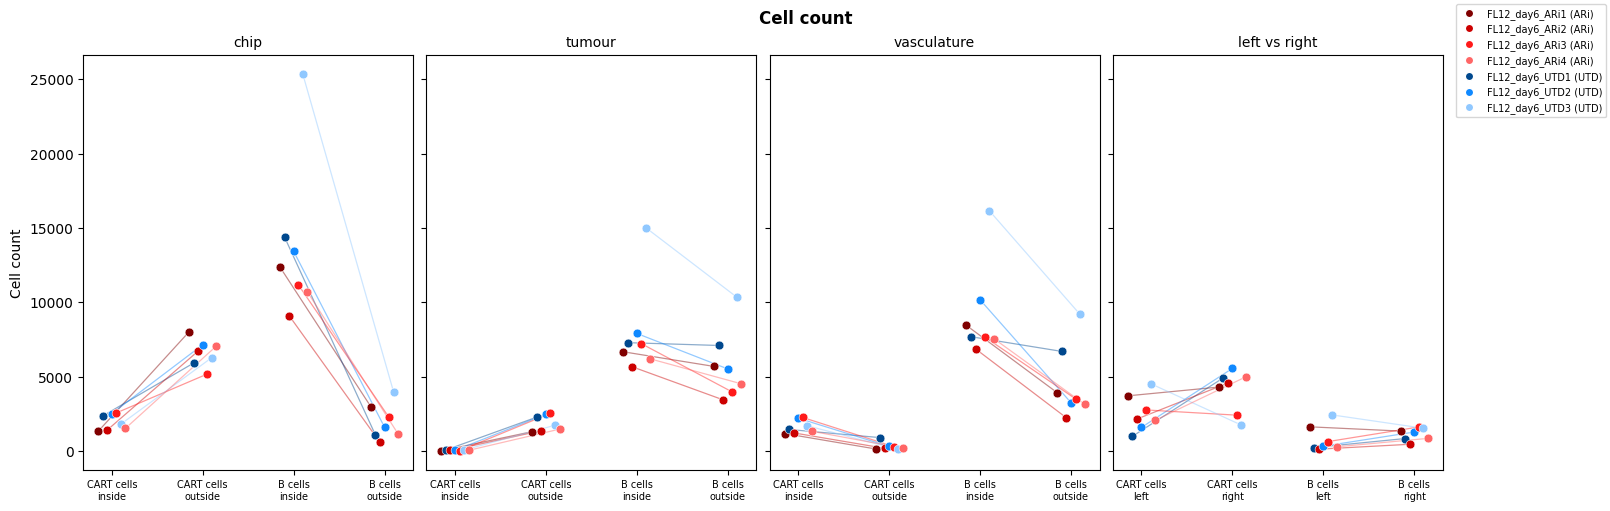

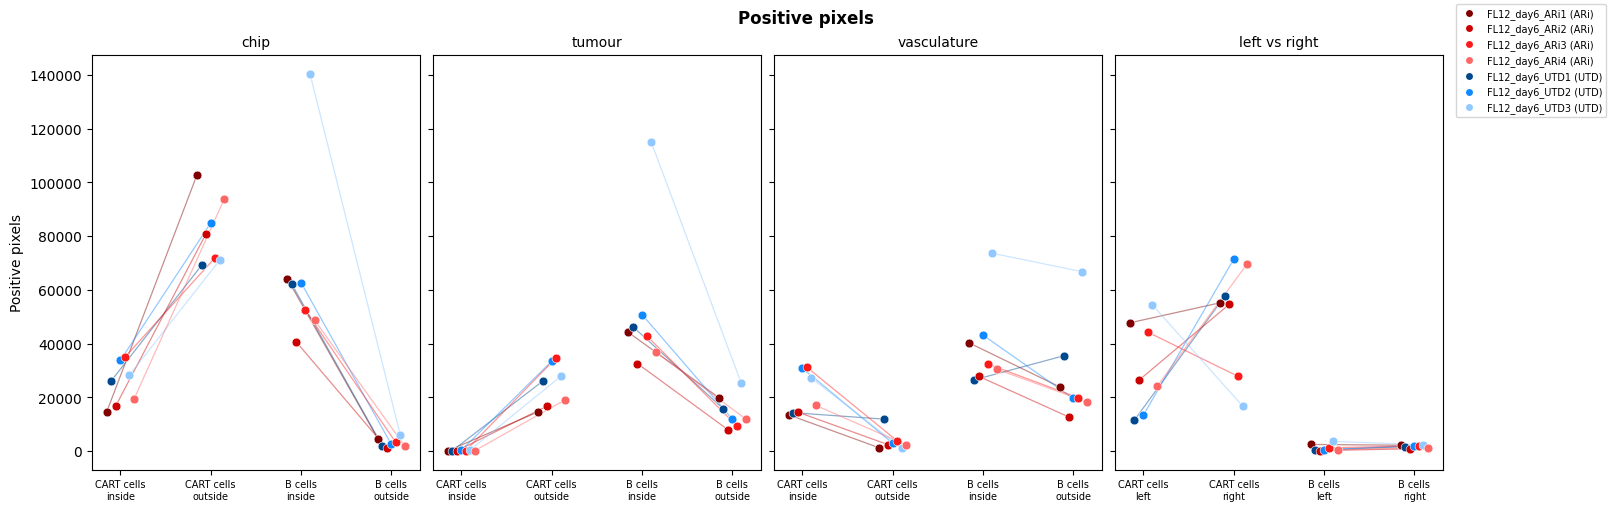

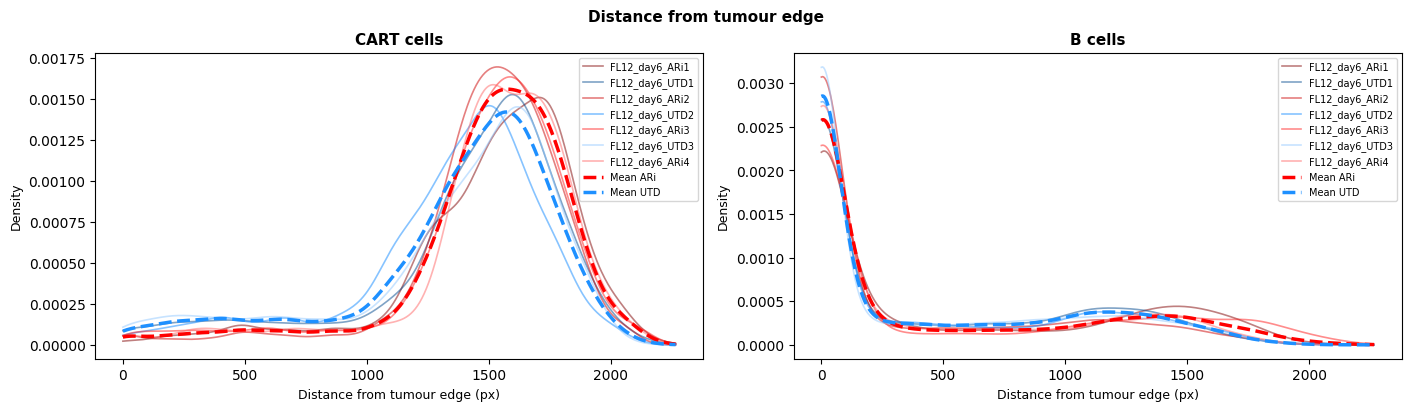

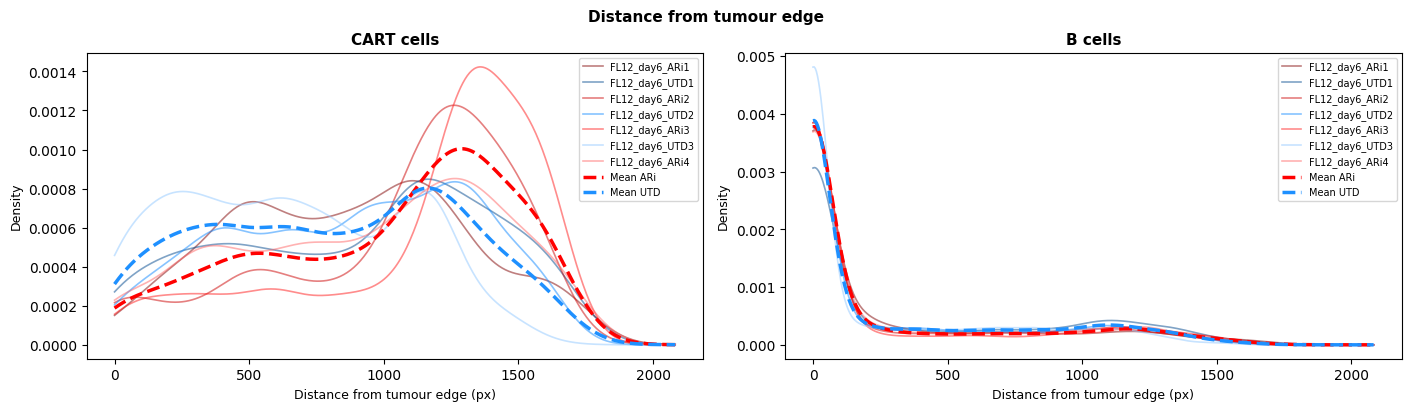

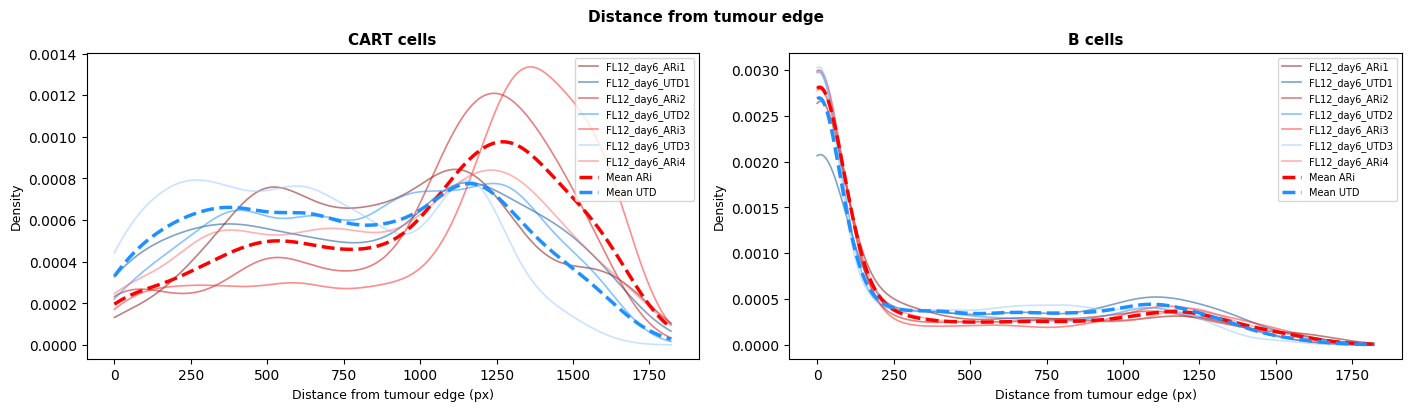

In [21]:
# 2) Define a palette for each condition
CONDITION_PALETTE = {
    "ARi_day6": "#ff0000",       # red
    "ARi_day7": "#ff8800",       # orange
    "UTD_day6": "#1e90ff",       # blue
    "UTD_day7": "#00cc88",       # teal
}
plot_swarmplots(all_results[(all_results["patient"]=="fl12") & (all_results["day"]=="6")], save_title="fl12_d6")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") ], save_title="fl12_d6_all_cells")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") & (all_distances["in_chip"]== True)], save_title="fl12_d6_in_chip")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") & (all_distances["in_vasculature"] == True) & (all_distances["in_chip"]== True)], save_title="fl12_d6_in_chip_AND_in_vasculature")

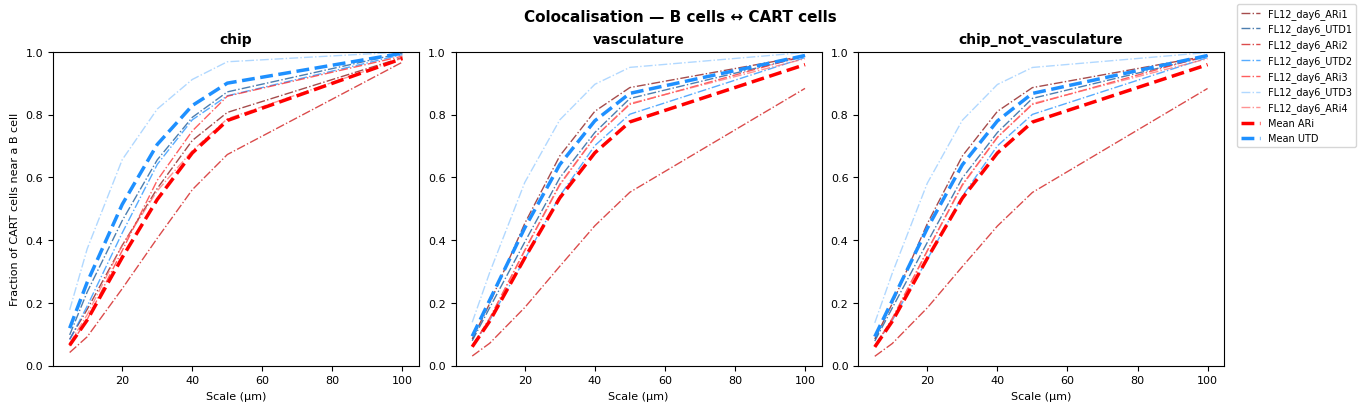

In [22]:
# Show just CART_near_B
plot_colocalisation(coloc_df[(coloc_df["day"] == "6") & (coloc_df["patient"] == "fl12")], methods=["CART_near_B"], save_title="d6_fl12_cart_near_B")

# Show just B_near_CART
# plot_colocalisation(_coloc_sub, methods=["B_near_CART"])

# Show just coarse Pearson
# plot_colocalisation(_coloc_sub, methods=["coarse_pearson"])

# Show all three methods at once
# plot_colocalisation(_coloc_sub)
